## 🔵 Putting it all together:

1. Importing the Main Libraries
2. Set up device-agnostic code
3. Data
4. Splitting the data
5. Visualize it

**Second step** of our PyTorch workflow: (building or picking a model)

6. Building a model
7. Set the manual seed
8. Make an instance of your model

**Third step** of our PyTorch workflow: (Training a Model)

9. 

#### 🟢 1. Importing Main Libraries

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt

# Chech the PyTorch version:
torch.__version__

'2.8.0'

Create device-agnostic code.

This means if we've got access to a GPU, our code will use it (for potentially faster computing)

If no GPU is available, the code will default to using a CPU. 

(For now, we have CPU only and to have GPU we have to either set it up locally or we have to use Google Colab)

#### 🟢 2. Set Up Device-Agnostic Code

In [3]:
# setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device cpu


#### 🟢 3. Data

In [ ]:
# Create some data using the linear regression models formula:
weight = 0.3
bias = 0.1

# create the range:
start = 0
end = 1
step = 0.02 

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1) # need to not face error
y = weight * X + bias 

# testing our result:
print(X[:10])
print(y[:10])

#### 🟢 4. Splitting the data

In [15]:
# split data:
train_split = int(0.8 * len(X)) # 80% of numbers of X
X_train = X[:train_split]
X_test = X[train_split:]

y_train_target = y[:train_split]
y_test_target = y[train_split:]

# testing our result:
print(f" X_train: {len(X_train)} X_test: {len(X_test)}") 
print(f" y_train_target: {len(y_train_target)} y_test_target: {len(y_test_target)}")

 X_train: 40 X_test: 10
 y_train_target: 40 y_test_target: 10


#### 🟢 5. Plot the Data:

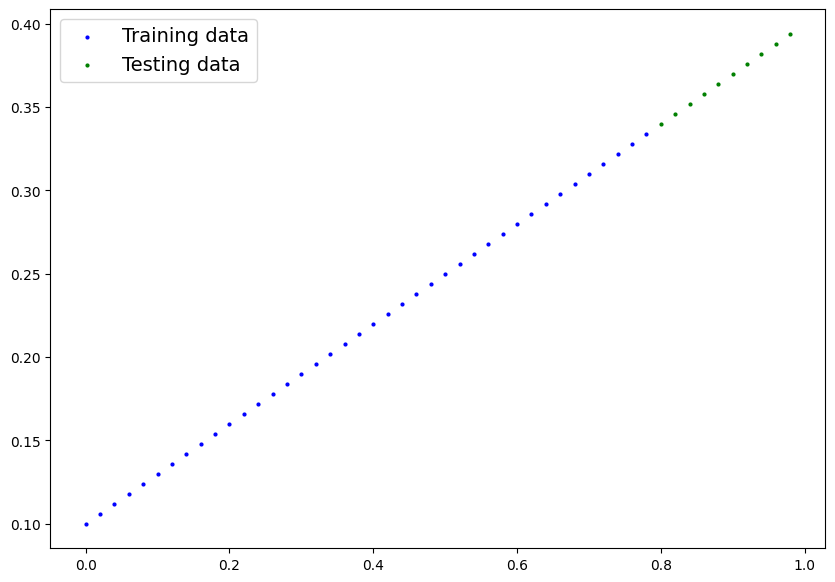

In [17]:
def plot_perdictions(train_data=X_train, 
                     train_labels=y_train_target, 
                     test_data=X_test, 
                     test_labels=y_test_target, 
                     perdictions=None):
    '''
        Plots training data, test data and compares predictions. 
    '''
    plt.figure(figsize=(10, 7))

    # Plot training data in blue:
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot testing data in blue:
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")


    # Are there perdictions?
    if perdictions is not None:
        # Plot the perdictions if they exist:

        plt.scatter(test_data, perdictions, c="r", s=4, label="Perdictions")

    # Show the legend:
    plt.legend(prop={"size":14})

    '''
    New Functions:
        1. Plotting the data as a graph:
            plt.scatter(input_data(x), output_data(y), color (c="b/r/g/y"), 
                        size (s=int), label="nameOfData")

        2. Plotting the data info (Training data, Testsing data, ...)
            plt.legend(prop={"size":int})
    '''

plot_perdictions(X_train, y_train_target, X_test, y_test_target)

### 🔵 Building or Choosing a Model

In [22]:
# Create a linear model by subclassing nn.Modeule

class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Use nn.Linear() for creating the model parameters
        self.linear_layer = nn.Linear(in_features=1, 
                                     out_features=1)

        # So behind the scenes, this thing is doing the linear regression model
        # formula, and it's choosing its parameter randomly.

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

# set the manual seed
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))